# Algoritmos de Inteligência Artificial Bioinspirados - Otimização Por Colônia de Formigas - 5 vértices

Representaremos as arestas de um grafo arbitrário da seguinte forma:

In [ ]:
import random

ab = ['AB', ['BC', 'BD', 'BE'], 8, 1]
ac = ['AC', ['CB', 'CD', 'CE'], 14, 1]
ad = ['AD', ['DE'], 22, 1]
ae = ['AE', [], 23, 1]

bc = ['BC', ['CD', 'CE'], 9, 1]
bd = ['BD', ['DC', 'DE'], 11, 1]
be = ['BE', [], 6, 1]

cb = ['CB', ['BD', 'BE'], 9, 1]
cd = ['CD', ['DE'], 10, 1]
ce = ['CE', [], 5, 1]

de = ['DE', [], 12, 1]
dc = ['DC', ['CE'], 10, 1]

arests = [ab, ac, ad, ae, bc, bd, be, cb, cd, ce, de, dc]


: 

In [ ]:
cd[2]
ac[1]

: 

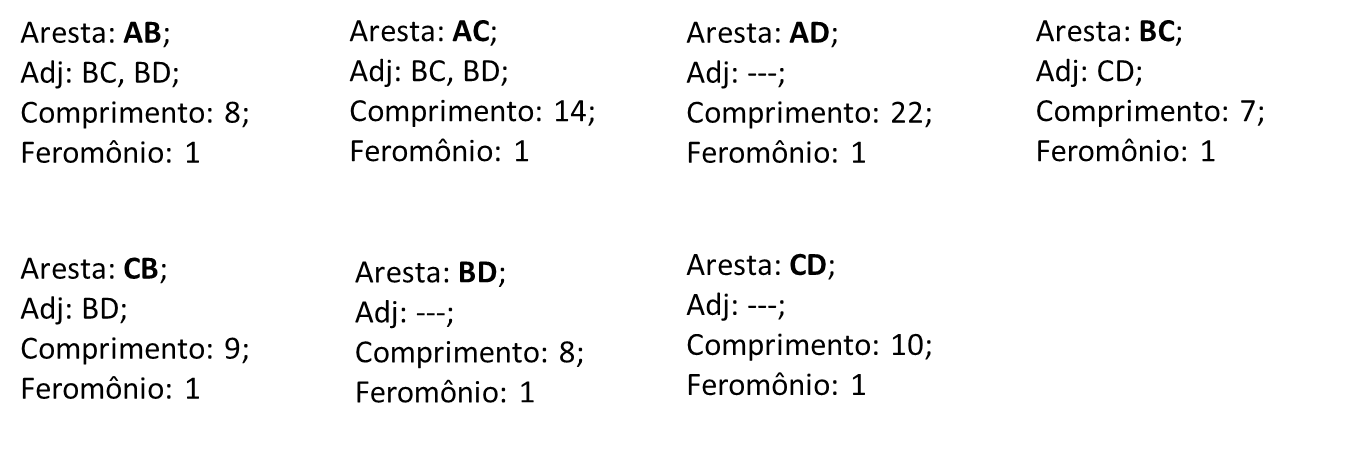

Função de probabilidade de escolha de aresta adjacente

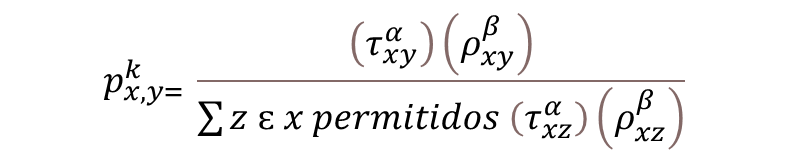

In [ ]:
def probabs(adja):
  dists = []
  fer = []
  for i in adja:
    for j in arests:
      if j[0] == i:
        dists.append(j[2])
        fer.append(j[3])

  atratividades = []
  cont = 0
  while cont < len(adja):
    atract = fer[cont]*(1/dists[cont])
    atratividades.append(atract)
    cont += 1

  soma = sum(atratividades)
  probs = []
  for i in atratividades:
    prob = (i/soma)
    probs.append(prob)
  return probs


: 

In [ ]:
probabs(['AB'])

: 

Escolha de aresta adjacente

In [ ]:
def escolhaAresta(adjs):
  probab = probabs(adjs)
  limiares = []
  soma = 0
  for i in probab:
    soma += i
    limiares.append(soma)
  r = random.random()
  cont = 0
  for i in limiares:
    if r > i:
      cont += 1
  return adjs[cont]

: 

In [ ]:
probabs(['AB','AC','AD'])

: 

In [ ]:
escolhaAresta(['AB','AC','AD'])

: 

Função formiga/caminho/solução

In [ ]:
def formiga(): #gera um caminho possível
  caminho = []
  #iniciais = [ab,ac,ad]

  #escolhendo a aresta inicial
  inicial = escolhaAresta(['AB','AC','AD'])
  caminho.append(inicial)

  if 'D' in caminho[-1]:
    return caminho
  else:
    while True:
      for i in arests:
        if caminho[-1] == i[0]:
          adj = i[1]
          if len(adj)==0:
            break
          else:
            adj_random = escolhaAresta(adj)
            caminho.append(adj_random)
      return caminho
      break


: 

In [ ]:
formiga()

: 

Comprimento de cada caminho/solução

In [ ]:
def comprimento(formiga):
  soma = 0
  for i in formiga:
    for j in arests:
      if i == j[0]:
        soma += j[2]
  return soma


: 

In [ ]:
comprimento(['AC','CD'])

: 

Atualização dos níveis de feromônio: evaporação e adição

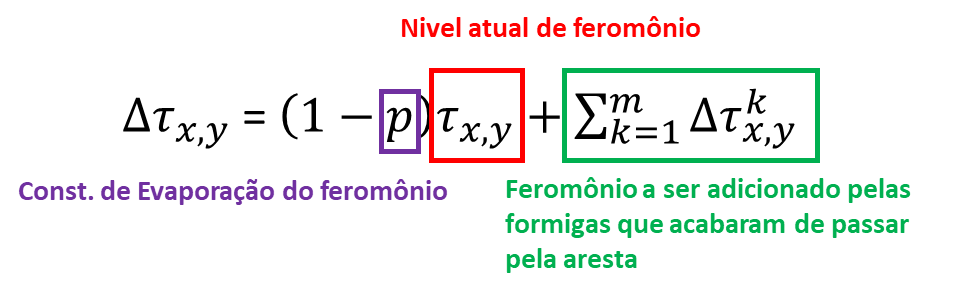

In [ ]:
#Evaporação do feromônio
def evaporacao(evap):
  for i in arests:
    i[3] = i[3]*(1-evap)

#Adição do feromônio

def atualiza_ferom(formigas):
  for i in formigas:
    ferom = 1/(comprimento(i))
    for j in i:
      for k in arests:
        if k[0] == j:
          k[3] = k[3] + ferom

: 

In [ ]:
for i in arests:
  print(i)

: 

In [ ]:
evaporacao(0.3)

for i in arests:
  print(i)

: 

In [ ]:
formigas = [['AB','BD'],['AD']]
atualiza_ferom(formigas)

for i in arests:
  print(i)

: 

Execução do algoritmo

In [ ]:
#Execucao do algoritmo
for i in range(30):
  evaporacao(0.3)
  formigas = []
  for j in range(5): #criar 5 formigas por interação
    formigas.append(formiga())
  atualiza_ferom(formigas)

for i in arests:
  print(i[0],i[3])

for k in formigas:
  print(k)



: 

: 